<a href="https://colab.research.google.com/github/Anindri/NPTEL_OptimizationInML/blob/main/W3_L4_SVD_PCA_FacesData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import logging

from numpy.random import RandomState
import matplotlib.pyplot as plt
#call library sci-kit learn
from sklearn.datasets import fetch_olivetti_faces
from sklearn import cluster
from sklearn import decomposition #library has PCA

rng=RandomState(0)

logging.basicConfig(level = logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

faces, _ = fetch_olivetti_faces(return_X_y=True, shuffle=True, random_state=rng)
n_samples,n_features=faces.shape

faces_centered = faces-faces.mean(axis=0)
faces_centered-=faces_centered.mean(axis=1).reshape(n_samples, -1)

print("Dataset consists of %d faces" % n_samples)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Dataset consists of 400 faces


In [3]:
n_row, n_col = 3,3
n_components= n_row*n_col
image_shape=(64,64) #each face is 64X64 image
#dataset is 400X4096  where number of faces is 400, size of each image is 4096

def plot_gallery(title, images, n_col=n_col,n_rown=n_row, cmap=plt.cm.gray):

  fig,axs=plt.subplots(
      nrows=n_row,
      ncols=n_col,
      figsize=(2.0*n_col,2.3*n_row),
      facecolor="white",
      constrained_layout=True,
)
  fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.02,hspace=0,wspace=0)
  fig.set_edgecolor("black")
  fig.suptitle(title,size=16)
  for ax,vec in zip(axs.flat,images):
    vmax=max(vec.max(),-vec.min())
    im=ax.imshow(vec.reshape(image_shape),cmap=cmap,
                 interpolation="nearest",
                 vmin=-vmax,
                 vmax=vmax)
    ax.axis("off")
  fig.colorbar(im,  ax=axs, orientation="horizontal",shrink=0.99,aspect=40, pad=0.01)
  plt.show()


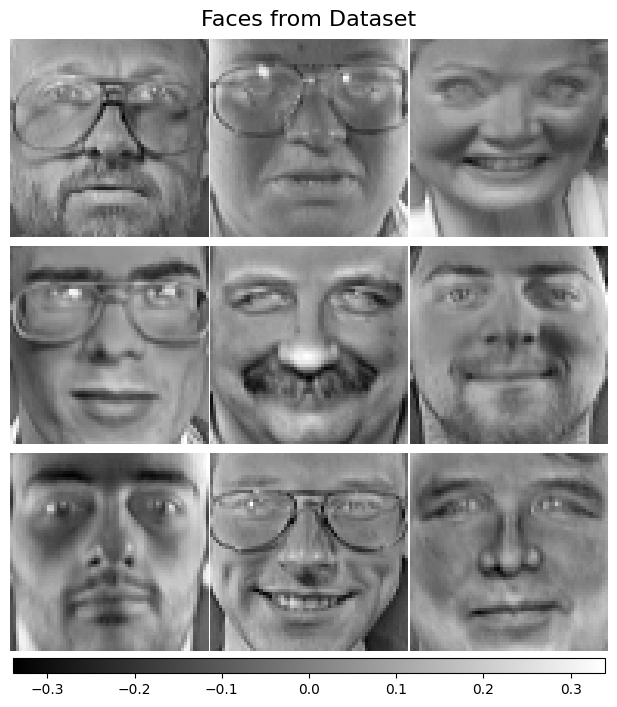

In [4]:
plot_gallery("Faces from Dataset", faces_centered[:n_components])

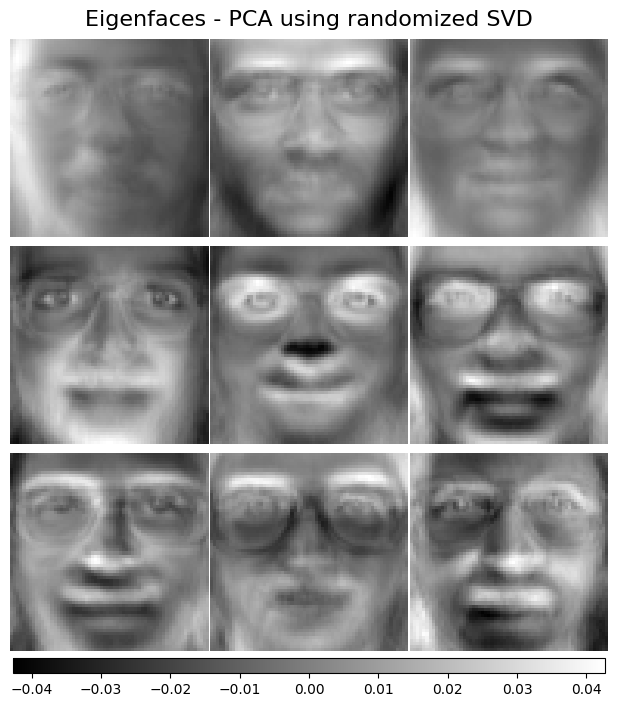

In [14]:
#Finiding the PCA
pca_estimator = decomposition.PCA(
    n_components=40,svd_solver="full", whiten=True

)
pca_estimator.fit(faces_centered)#fitting the matrix into decomposition for PCA
plot_gallery("Eigenfaces - PCA using randomized SVD",pca_estimator.components_[:n_components]
)
#faces_centered is the matrix


In [7]:
faces_centered.shape #matrix shape

(400, 4096)

In [8]:
pca_estimator.components_.shape

(400, 4096)

In [9]:
pca_estimator.components_

array([[ 2.85012126e-02,  3.21028009e-02,  3.57243940e-02, ...,
        -2.56915595e-02, -2.24477984e-02, -2.03094278e-02],
       [ 9.13895143e-04,  5.99190971e-05,  1.00975798e-03, ...,
        -2.00162735e-02, -1.86901800e-02, -1.66746508e-02],
       [ 1.05346255e-02,  3.26586142e-03, -8.05994682e-03, ...,
         5.47986291e-02,  5.60211912e-02,  5.34061529e-02],
       ...,
       [ 2.33219890e-03,  2.05312334e-02,  1.49193062e-02, ...,
        -1.28708649e-02, -5.82088567e-02, -7.67504498e-02],
       [ 1.76850948e-02,  2.91470848e-02, -9.83637571e-03, ...,
         1.64149143e-03,  1.29781170e-02, -8.14286806e-03],
       [-6.45679515e-03,  2.78185636e-01, -1.34626001e-01, ...,
         2.73179845e-03, -2.54065115e-02,  2.79660337e-03]], dtype=float32)

In [10]:
pca_estimator.singular_values_

array([6.71295471e+01, 5.02596626e+01, 4.19929085e+01, 3.72719421e+01,
       3.17804623e+01, 2.88026371e+01, 2.54703312e+01, 2.53372707e+01,
       2.31128082e+01, 2.24694691e+01, 2.13066082e+01, 2.00947323e+01,
       1.94818726e+01, 1.83656006e+01, 1.77946396e+01, 1.72280407e+01,
       1.63568954e+01, 1.54267740e+01, 1.53864660e+01, 1.49818735e+01,
       1.40874462e+01, 1.37457342e+01, 1.34967546e+01, 1.31533537e+01,
       1.29577913e+01, 1.27904634e+01, 1.25121155e+01, 1.20818577e+01,
       1.18217535e+01, 1.12980604e+01, 1.11244287e+01, 1.07615156e+01,
       1.03474684e+01, 1.01499949e+01, 9.99113941e+00, 9.96174908e+00,
       9.72128773e+00, 9.43831158e+00, 9.33585835e+00, 9.07176113e+00,
       8.99592781e+00, 8.88079071e+00, 8.78388596e+00, 8.62940216e+00,
       8.53515053e+00, 8.41360950e+00, 8.37668610e+00, 8.21579456e+00,
       8.04652691e+00, 7.92377186e+00, 7.80454731e+00, 7.75971365e+00,
       7.57668877e+00, 7.50781298e+00, 7.41539001e+00, 7.35958338e+00,
      

In [ ]:
#in facial recognition software they find the PCA of the said face picture, and find the angle between it's PCA components to the PCA components of the face images stored in the dataset
#since the dimension has been reduced, the process is a lot faster.